In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

### Plot of the initial value to best fit value difference

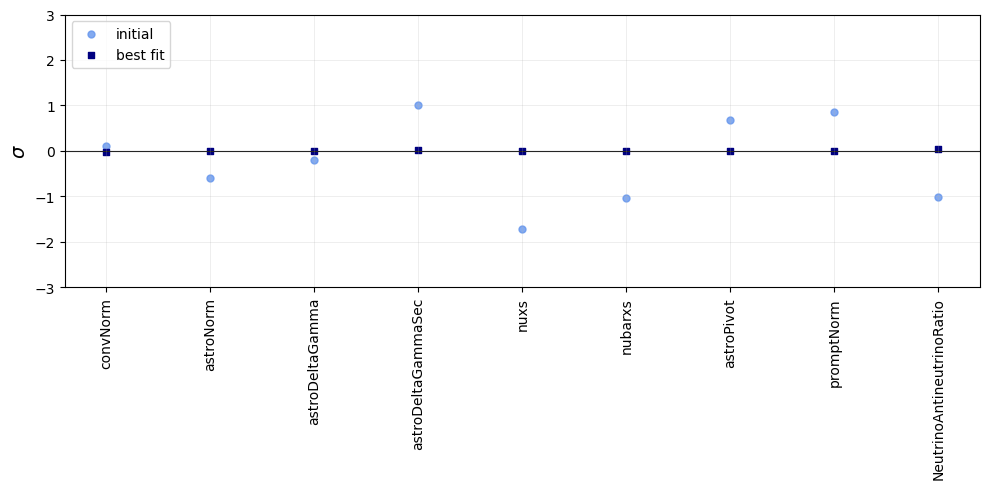

In [2]:
# 1. Input Data
init_raw = {
    "convNorm": 1.0485, "astroNorm": 5.4641,
    "astroDeltaGamma": 0.3319, "astroDeltaGammaSec": 0.5729, "nuxs": 0.8289,
    "nubarxs": 0.8969, "astroPivot": 5.3415, "promptNorm": 2.2959,
    "NeutrinoAntineutrinoRatio": 0.4887
}

fit_raw = {
    "convNorm": 1.0044, "astroNorm": 6.3702,
    "astroDeltaGamma": 0.3703, "astroDeltaGammaSec": 0.3751, "nuxs": 1.0000,
    "nubarxs": 1.0000, "astroPivot": 5.0024, "promptNorm": 0.0070,
    "NeutrinoAntineutrinoRatio": 1.0162
}

# 2. Prior Definitions
# Enter your actual prior means and standard deviations here.
# By default, I am setting the mean to the Fit value to center them at 0.
# Update 'prior_sigmas' with your actual values.
prior_means = {
    "convNorm": 1.01, "astroNorm": 6.37,
    "astroDeltaGamma": 0.37, "astroDeltaGammaSec": 0.37, "nuxs": 1.0000,
    "nubarxs": 1.0000, "astroPivot": 5.00, "promptNorm": 0.00,
    "NeutrinoAntineutrinoRatio": 1.0
}
prior_sigmas = {
    "convNorm": 0.68/2, "astroNorm": 3.08/2,
    "astroDeltaGamma": 0.4/2, "astroDeltaGammaSec": 0.4/2, "nuxs": 0.1000,
    "nubarxs": 0.10000, "astroPivot": 1.00/2, "promptNorm": 5.34/2,
    "NeutrinoAntineutrinoRatio": 1.0/2
} # REPLACE 1.0 with your sigma values

# Example overrides (adjust as needed):
# prior_sigmas['convNorm'] = 0.4
# prior_sigmas['domEfficiency'] = 0.1

# 3. Calculate Pulls
params = list(fit_raw.keys())
init_pulls = [(init_raw[p] - prior_means[p]) / prior_sigmas[p] for p in params]
fit_pulls = [(fit_raw[p] - prior_means[p]) / prior_sigmas[p] for p in params]

# 4. Plotting
plt.figure(figsize=(10, 5))

# Plot initial values (light blue circles)
plt.scatter(params, init_pulls, color='#6495ED', label='initial', marker='o', s=25, alpha=0.8)

# Plot best fit values (dark blue squares)
plt.scatter(params, fit_pulls, color='#000080', label='best fit', marker='s', s=25)

# Formatting
plt.axhline(0, color='black', linewidth=0.8, zorder=1)
plt.grid(True, which='both', linestyle='-', linewidth=0.5, alpha=0.3)
plt.ylabel(r'$\sigma$', fontsize=14)
plt.xticks(rotation=90)
plt.ylim(-3, 3) # Standard pull range
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()

plt.show()

### Plotting the histogram of the generated data

Loading Data/GollumFit_Data/modified_fake_data.npz...
Loaded 13061947 fake events (Note: these are weighted MC events)
Binning data...
Generating plot...
Plot saved successfully to Data/GollumFit_Data/histograms/test_dataset_histogram.png


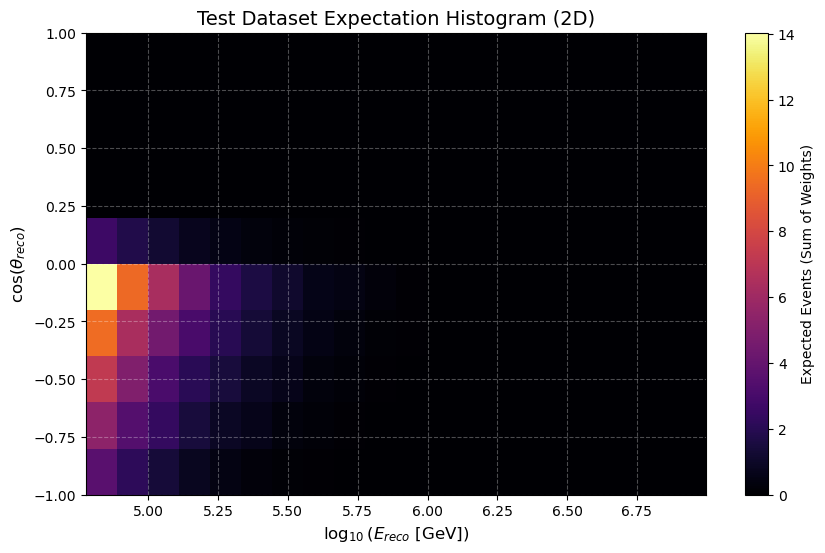

In [7]:
# Load the generated fake data

data_path = "Data/GollumFit_Data/modified_fake_data.npz"
if not os.path.exists(data_path):
    print(f"File not found: {data_path}")
    exit()
    
print(f"Loading {data_path}...")
# 'realization' is the key used when saving in HESE_75_GollumFit.py
data = np.load(data_path)["realization"]

energy = data[:, 0]
zenith = data[:, 1]
weights = data[:, 3]

print(f"Loaded {len(data)} fake events (Note: these are weighted MC events)")

# Steering parameters for binning matched from HESE_75_GollumFit.py
minFitEnergy = 60000.0  # 60 TeV
maxFitEnergy = 1e7      # 10 PeV
logEbinWidth = 0.111

# Generate log10(Energy) bin edges
# We add logEbinWidth/2 to the upper bound to ensure numpy includes the final edge
logE_bins = np.arange(np.log10(minFitEnergy), np.log10(maxFitEnergy) + logEbinWidth/2, logEbinWidth)

# Zenith limits are in cosine, and Zenith values are in radians in the dataset
cosTh_bins = np.arange(-1.0, 1.0 + 0.1, 0.2)

# Calculate cos(Zenith) for binning
cos_zenith = np.cos(zenith)

print("Binning data...")
# Histogram it using Weights as probabilities/counts
# x is log10(energy), y is cos(zenith)
H, xedges, yedges = np.histogram2d(
    np.log10(energy), 
    cos_zenith, 
    bins=[logE_bins, cosTh_bins], 
    weights=weights
)

# Transpose H because numpy returns (x_bins, y_bins) but pcolormesh expects (y, x)
H = H.T

print("Generating plot...")
plt.figure(figsize=(10, 6))

# Use pcolormesh to draw the 2D histogram
X, Y = np.meshgrid(xedges, yedges)
mesh = plt.pcolormesh(X, Y, H, cmap='inferno', shading='flat') # 'inferno' looks great for astro 2D histograms

# Add a colorbar to represent Expected Count
plt.colorbar(mesh, label="Expected Events (Sum of Weights)")

plt.xlabel(r'$\log_{10}(E_{reco}$ $[\mathrm{GeV}])$', fontsize=12)
plt.ylabel(r'$\cos(\theta_{reco})$', fontsize=12)
plt.title('Test Dataset Expectation Histogram (2D)', fontsize=14)
plt.grid(True, alpha=0.3, color='white', linestyle='--')

# Save the plot
output_path = "Data/GollumFit_Data/histograms/test_dataset_histogram.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {output_path}")

### Plotting the histogram of the real data

Loading Data/HESE/HESE 7.5 Data Release/resources/data/HESE_data.json...
Loaded 60 real events
Binning data...
Generating plot...
Plot saved successfully to Data/GollumFit_Data/histograms/real_dataset_histogram.png


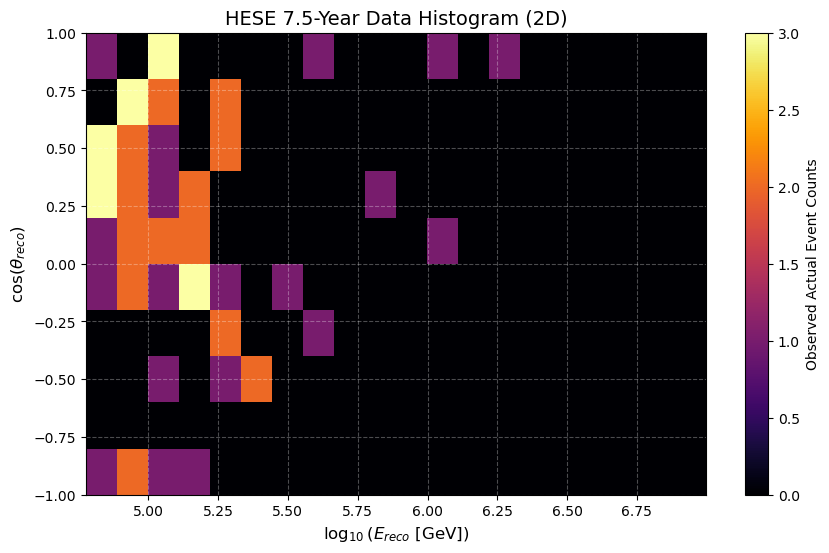

In [11]:
sys.path.append("Data/HESE/HESE 7.5 Data Release")
import data_loader

data_file = "Data/HESE/HESE 7.5 Data Release/resources/data/HESE_data.json"

if not os.path.exists(data_file):
    print(f"File not found: {data_file}")
    exit()
    
print(f"Loading {data_file}...")
HESE_Dat = data_loader.load_data(data_file)

# Extract structural array data
energy = HESE_Dat["recoDepositedEnergy"]
zenith = HESE_Dat["recoZenith"]

# For real data, each observation is 1 physical count (weight = 1)
weights = np.ones(len(energy))

print(f"Loaded {len(energy)} real events")

# Steering parameters matched from HESE_75_GollumFit.py
minFitEnergy = 60000.0  # 60 TeV
maxFitEnergy = 1e7      # 10 PeV
logEbinWidth = 0.111

# Generate log10(Energy) bin edges
logE_bins = np.arange(np.log10(minFitEnergy), np.log10(maxFitEnergy) + logEbinWidth/2, logEbinWidth)

# Zenith limits are in cosine, and zenith is measured in radians
cosTh_bins = np.arange(-1.0, 1.0 + 0.1, 0.2)
cos_zenith = np.cos(zenith)

print("Binning data...")
# Histogram it
H, xedges, yedges = np.histogram2d(
    np.log10(energy), 
    cos_zenith, 
    bins=[logE_bins, cosTh_bins], 
    weights=weights # all 1s
)

H = H.T

print("Generating plot...")
plt.figure(figsize=(10, 6))

X, Y = np.meshgrid(xedges, yedges)
mesh = plt.pcolormesh(X, Y, H, cmap='inferno', shading='flat') 

# The colorbar here represents actual physical integer counts!
plt.colorbar(mesh, label="Observed Actual Event Counts")

plt.xlabel(r'$\log_{10}(E_{reco}$ $[\mathrm{GeV}])$', fontsize=12)
plt.ylabel(r'$\cos(\theta_{reco})$', fontsize=12)
plt.title('HESE 7.5-Year Data Histogram (2D)', fontsize=14)
plt.grid(True, alpha=0.3, color='white', linestyle='--')

# Output path
os.makedirs("Data/GollumFit_Data", exist_ok=True)
output_path = "Data/GollumFit_Data/histograms/real_dataset_histogram.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {output_path}")